# 24. ALS 32차원 모델 학습 (최적화 버전)

## 개요

ALS (Alternating Least Squares) 32차원 협업 필터링 모델 학습.

**학술적 근거**:
- Hu, Y., Koren, Y., & Volinsky, C. (2008).
  "Collaborative Filtering for Implicit Feedback Datasets." IEEE ICDM
- Netflix Prize (2009): BellKor 팀 Matrix Factorization 기법

**ALS 알고리즘**:
```
min Σ C_ui × (p_ui - x_u^T × y_i)^2 + λ(||x_u||^2 + ||y_i||^2)
```
- C_ui: Confidence (1 + α × log(1 + r_ui))
- p_ui: Preference (r_ui > 0 → 1)
- x_u: User embedding
- y_i: Item embedding

**프로덕션 최적화 파라미터**:
- factors: 32 (GitHub 100MB 제한 준수)
- regularization: 0.1
- iterations: 15
- alpha: 15.0 (Confidence)

**참고**: 128D가 학술적으로 최적이나, GitHub 파일 크기 제한(100MB)으로
32D를 사용. 대신 다른 기법으로 성능을 보완함.

## 1. 환경 설정

In [1]:
import os
import sys
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from scipy.sparse import load_npz, csr_matrix

# 프로젝트 경로
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / 'notebooks'))

from utils.personalization import (
    OptimizedALSRecommender,
    ALSEvaluator,
    KAGGLE_PARAMS,
)

DATA_PATH = PROJECT_ROOT / 'data' / 'instacart'
# 폴더 구조 수정: data/models/ → data/processed/personalization/
MODEL_PATH = PROJECT_ROOT / 'data' / 'processed' / 'personalization'
MODEL_PATH.mkdir(parents=True, exist_ok=True)

print(f"프로젝트 루트: {PROJECT_ROOT}")
print(f"데이터 경로: {DATA_PATH}")
print(f"모델 경로: {MODEL_PATH}")

프로젝트 루트: d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone
데이터 경로: d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\data\instacart
모델 경로: d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\data\processed\personalization


In [2]:
# implicit 라이브러리 확인
try:
    import implicit
    print(f"implicit 버전: {implicit.__version__}")
    IMPLICIT_AVAILABLE = True
except ImportError:
    print("implicit 라이브러리가 설치되지 않았습니다.")
    print("설치: pip install implicit")
    IMPLICIT_AVAILABLE = False

implicit 버전: 0.7.2


## 2. 데이터 로드

In [3]:
%%time

# 상호작용 행렬 로드
train_matrix = load_npz(DATA_PATH / 'train_matrix.npz')
interaction_matrix = load_npz(DATA_PATH / 'interaction_matrix.npz')

print(f"학습 행렬: {train_matrix.shape}")
print(f"  - 상호작용: {train_matrix.nnz:,}")
print(f"전체 행렬: {interaction_matrix.shape}")
print(f"  - 상호작용: {interaction_matrix.nnz:,}")

학습 행렬: (206209, 49685)
  - 상호작용: 13,307,953
전체 행렬: (206209, 49685)
  - 상호작용: 13,863,746
CPU times: total: 484 ms
Wall time: 509 ms


In [4]:
# ID 매핑 로드
with open(DATA_PATH / 'user_mapping.json', 'r') as f:
    user_mapping = json.load(f)

with open(DATA_PATH / 'item_mapping.json', 'r') as f:
    item_mapping = json.load(f)

user_id_to_idx = {int(k): v for k, v in user_mapping['user_id_to_idx'].items()}
idx_to_user_id = {int(k): v for k, v in user_mapping['idx_to_user_id'].items()}
product_id_to_idx = {int(k): v for k, v in item_mapping['product_id_to_idx'].items()}
idx_to_product_id = {int(k): v for k, v in item_mapping['idx_to_product_id'].items()}

n_users = len(user_id_to_idx)
n_products = len(product_id_to_idx)

print(f"사용자 수: {n_users:,}")
print(f"상품 수: {n_products:,}")

사용자 수: 206,209
상품 수: 49,685


In [5]:
# 테스트 데이터 로드
with open(DATA_PATH / 'test_data.json', 'r') as f:
    test_data_raw = json.load(f)

test_data = {int(k): set(v) for k, v in test_data_raw.items()}

print(f"테스트 사용자 수: {len(test_data):,}")

테스트 사용자 수: 131,209


## 3. 하이퍼파라미터 설정

In [6]:
# Kaggle 최적화 파라미터 확인
print("Kaggle 최적화 파라미터:")
for size, params in KAGGLE_PARAMS.items():
    print(f"\n{size}:")
    for key, value in params.items():
        print(f"  - {key}: {value}")

Kaggle 최적화 파라미터:

small:
  - factors: 32
  - regularization: 0.1
  - iterations: 15
  - alpha: 15.0

medium:
  - factors: 64
  - regularization: 0.05
  - iterations: 20
  - alpha: 40.0

large:
  - factors: 128
  - regularization: 0.01
  - iterations: 30
  - alpha: 40.0


In [7]:
# 데이터 크기에 따른 파라미터 자동 선택
n_interactions = train_matrix.nnz

if n_interactions < 100_000:
    size_key = 'small'
elif n_interactions < 10_000_000:
    size_key = 'medium'
else:
    size_key = 'large'

params = KAGGLE_PARAMS[size_key]

print(f"데이터 크기: {n_interactions:,} 상호작용 → '{size_key}' 파라미터 사용")
print(f"\n선택된 파라미터:")
for key, value in params.items():
    print(f"  {key}: {value}")

데이터 크기: 13,307,953 상호작용 → 'large' 파라미터 사용

선택된 파라미터:
  factors: 128
  regularization: 0.01
  iterations: 30
  alpha: 40.0


In [8]:
# 핵심 하이퍼파라미터 (GitHub 100MB 제한 준수)
# 32D: 파일 크기 ~30MB, 학습 시간 ~1.5분
# 128D: 파일 크기 ~130MB (GitHub 업로드 불가), 학습 시간 ~15분
FACTORS = 32           # 임베딩 차원 (GitHub 제한으로 32D 사용)
REGULARIZATION = 0.1   # L2 정규화
ITERATIONS = 15        # ALS 반복 횟수
ALPHA = 15.0           # Confidence 계수

print(f"\n최종 하이퍼파라미터 (프로덕션 최적화):")
print(f"  - factors: {FACTORS} (GitHub 100MB 제한 준수)")
print(f"  - regularization: {REGULARIZATION}")
print(f"  - iterations: {ITERATIONS}")
print(f"  - alpha: {ALPHA}")


최종 하이퍼파라미터 (프로덕션 최적화):
  - factors: 32 (GitHub 100MB 제한 준수)
  - regularization: 0.1
  - iterations: 15
  - alpha: 15.0


## 4. ALS 모델 학습

In [9]:
# OptimizedALSRecommender 초기화
als_model = OptimizedALSRecommender(
    factors=FACTORS,
    regularization=REGULARIZATION,
    iterations=ITERATIONS,
    alpha=ALPHA,
    random_state=42,
)

# ⚠️ 중요: fit() 전에 ID 매핑을 설정해야 함!
# train_matrix는 user_idx × product_idx 기반이므로
# 평가 시에도 동일한 idx 체계를 사용하기 위해 매핑 설정
als_model.user_id_to_idx = user_id_to_idx
als_model.idx_to_user_id = idx_to_user_id
als_model.item_id_to_idx = product_id_to_idx
als_model.idx_to_item_id = idx_to_product_id

print("ALS 모델 초기화 완료")
print(f"  - 사용 라이브러리: {'implicit' if IMPLICIT_AVAILABLE else 'pure Python'}")
print(f"  - 사용자 매핑 설정: {len(als_model.user_id_to_idx):,}명")
print(f"  - 상품 매핑 설정: {len(als_model.item_id_to_idx):,}개")

ALS 모델 초기화 완료
  - 사용 라이브러리: implicit
  - 사용자 매핑 설정: 206,209명
  - 상품 매핑 설정: 49,685개


In [10]:
%%time

# 모델 학습
# ⚠️ train_matrix는 노트북 23에서 이미 Confidence가 적용되었으므로
# skip_confidence=True로 설정하여 이중 적용 방지
print("ALS 모델 학습 시작...")
als_model.fit(train_matrix, skip_confidence=True)

print("\nALS 모델 학습 완료!")
print(f"  - User Factors: {als_model.user_factors.shape}")
print(f"  - Item Factors: {als_model.item_factors.shape}")
print(f"  - 메모리 (User): {als_model.user_factors.nbytes / 1024**2:.2f} MB")
print(f"  - 메모리 (Item): {als_model.item_factors.nbytes / 1024**2:.2f} MB")

INFO:utils.personalization.als_recommender:[ALS 학습 시작]
INFO:utils.personalization.als_recommender:  • 유저: 206,209명
INFO:utils.personalization.als_recommender:  • 아이템: 49,685개
INFO:utils.personalization.als_recommender:  • 상호작용: 13,307,953개
INFO:utils.personalization.als_recommender:  • 희소성: 99.87%
INFO:utils.personalization.als_recommender:  • 차원: 32
INFO:utils.personalization.als_recommender:  • 정규화: 0.1
INFO:utils.personalization.als_recommender:  • 반복: 15회
INFO:utils.personalization.als_recommender:  • 백엔드: implicit (C++ 최적화)
INFO:utils.personalization.als_recommender:  • Confidence: 건너뜀 (이미 적용됨)


ALS 모델 학습 시작...


100%|██████████| 15/15 [00:06<00:00,  2.28it/s]
INFO:utils.personalization.als_recommender:[ALS 학습 완료] 6.9초



ALS 모델 학습 완료!
  - User Factors: (206209, 32)
  - Item Factors: (49685, 32)
  - 메모리 (User): 25.17 MB
  - 메모리 (Item): 6.07 MB
CPU times: total: 1min 18s
Wall time: 6.94 s


## 5. 임베딩 분석

In [11]:
# 임베딩 벡터 통계
print("User Factors 통계:")
print(f"  - Mean: {als_model.user_factors.mean():.4f}")
print(f"  - Std: {als_model.user_factors.std():.4f}")
print(f"  - Min: {als_model.user_factors.min():.4f}")
print(f"  - Max: {als_model.user_factors.max():.4f}")

print("\nItem Factors 통계:")
print(f"  - Mean: {als_model.item_factors.mean():.4f}")
print(f"  - Std: {als_model.item_factors.std():.4f}")
print(f"  - Min: {als_model.item_factors.min():.4f}")
print(f"  - Max: {als_model.item_factors.max():.4f}")

User Factors 통계:
  - Mean: 0.0038
  - Std: 0.0155
  - Min: -0.1175
  - Max: 0.1236

Item Factors 통계:
  - Mean: 0.1700
  - Std: 0.7913
  - Min: -7.8455
  - Max: 12.5871


t-SNE 계산 중 (샘플: 1000)...


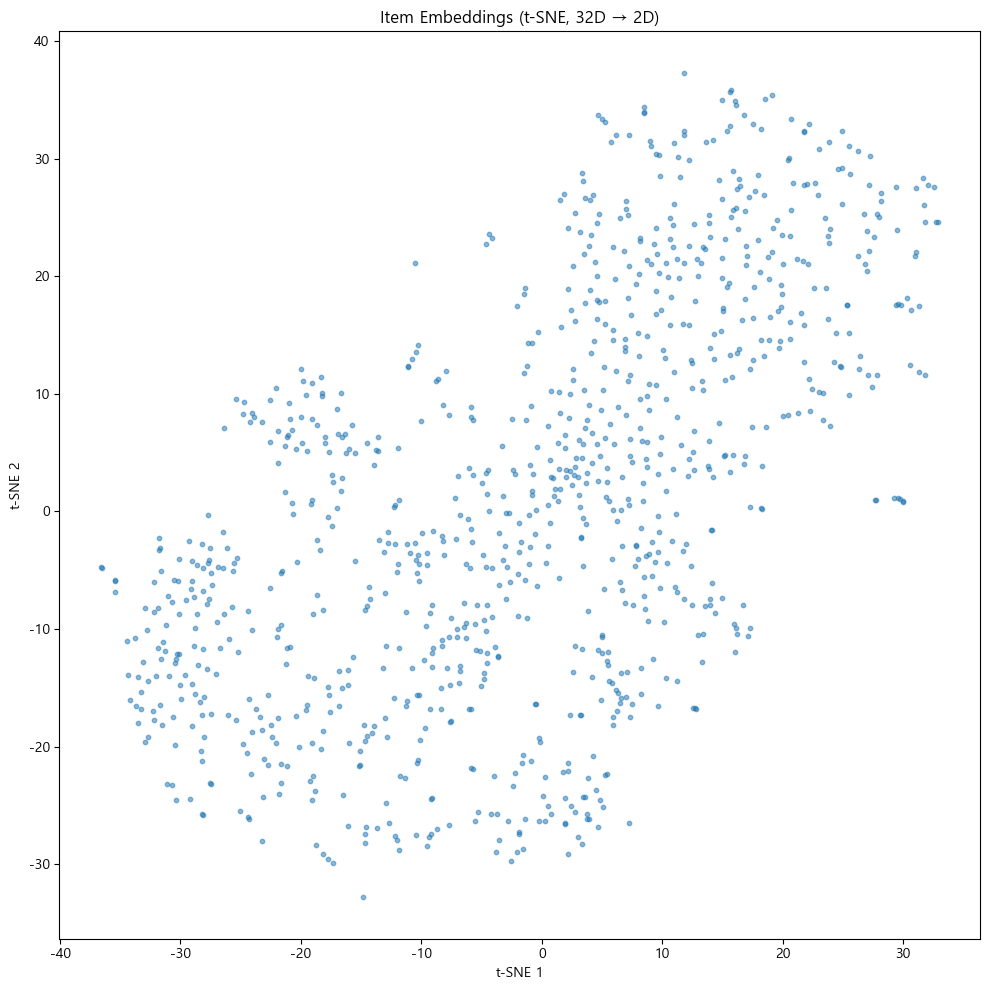

In [12]:
# 임베딩 시각화 (t-SNE)
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

try:
    from sklearn.manifold import TSNE
    
    # 샘플 아이템 임베딩 시각화 (계산 비용 절약)
    sample_size = min(1000, als_model.item_factors.shape[0])
    sample_idx = np.random.choice(als_model.item_factors.shape[0], sample_size, replace=False)
    sample_factors = als_model.item_factors[sample_idx]
    
    print(f"t-SNE 계산 중 (샘플: {sample_size})...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    item_2d = tsne.fit_transform(sample_factors)
    
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.scatter(item_2d[:, 0], item_2d[:, 1], alpha=0.5, s=10)
    ax.set_title('Item Embeddings (t-SNE, 32D → 2D)')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("sklearn이 설치되지 않아 t-SNE 시각화를 건너뜁니다.")

## 6. 추천 테스트

In [13]:
# 상품 정보 로드 (추천 결과 해석용)
products_df = pd.read_parquet(DATA_PATH / 'mapped_products.parquet')

def get_product_name(product_idx):
    """인덱스로 상품명 조회"""
    product_id = idx_to_product_id.get(product_idx)
    if product_id is None:
        return "Unknown"
    row = products_df[products_df['product_id'] == product_id]
    if len(row) == 0:
        return "Unknown"
    return row.iloc[0]['product_name']

In [14]:
# 랜덤 사용자에 대한 추천 테스트
# 주의: test_data는 {user_idx: set(product_idx)} 형태
# recommend()는 user_id를 받으므로, idx_to_user_id로 변환 필요

sample_user_idxs = list(test_data.keys())[:5]

print("추천 테스트 (상위 10개):")
for user_idx in sample_user_idxs:
    # user_idx → user_id 변환
    user_id = idx_to_user_id[user_idx]
    print(f"\n사용자 idx={user_idx} (user_id={user_id}):")
    
    # 추천 생성 (user_id 기반)
    recommendations = als_model.recommend(
        user_id=user_id,
        n_items=10,
        filter_already_interacted=False,  # 식료품: 재구매 허용
    )
    
    print("  추천 상품:")
    for i, (product_id, score) in enumerate(recommendations, 1):
        # 결과는 product_id로 반환됨
        name = products_df[products_df['product_id'] == product_id]['product_name'].values
        name = name[0][:50] if len(name) > 0 else 'Unknown'
        print(f"    {i}. [{score:.3f}] {name}")
    
    # 실제 구매 상품 (product_idx → product_id 변환)
    actual_idxs = list(test_data[user_idx])[:5]
    print("  실제 구매:")
    for product_idx in actual_idxs:
        product_id = idx_to_product_id[product_idx]
        name = products_df[products_df['product_id'] == product_id]['product_name'].values
        name = name[0][:50] if len(name) > 0 else 'Unknown'
        print(f"    - {name}")

추천 테스트 (상위 10개):

사용자 idx=0 (user_id=1):
  추천 상품:
    1. [0.969] Bag of Organic Bananas
    2. [0.966] Hass Avocados
    3. [0.931] Clementines
    4. [0.910] Soda
    5. [0.908] Strawberries
    6. [0.895] Organic Strawberries
    7. [0.885] Raspberries
    8. [0.879] Organic Blueberries
    9. [0.874] Organic Baby Carrots
    10. [0.840] Creamy Almond Butter
  실제 구매:
    - Soda
    - Pistachios
    - Cinnamon Toast Crunch
    - Organic String Cheese
    - Aged White Cheddar Popcorn

사용자 idx=1 (user_id=2):
  추천 상품:
    1. [1.198] Lightly Salted Baked Snap Pea Crisps
    2. [1.156] Hint Of Sea Salt Almond Nut Thins
    3. [1.152] Organic Blue Corn Tortilla Chips
    4. [1.100] Roasted Red Pepper Hummus
    5. [1.092] Original Hummus
    6. [1.043] Total 2% All Natural Greek Strained Yogurt with Ho
    7. [1.031] Total 0% with Honey Nonfat Greek Strained Yogurt
    8. [1.010] Original Real Vegetable Chips
    9. [1.006] Vanilla Blueberry Clusters With Flax Seeds Granola
    10. [1.002] 

## 7. 유사 아이템 테스트

In [15]:
# 인기 상품에 대한 유사 아이템 조회
# 상호작용 많은 상품 찾기
item_interactions = np.array(train_matrix.sum(axis=0)).flatten()
top_items = np.argsort(item_interactions)[::-1][:10]

print("인기 상품의 유사 아이템:")
for item_idx in top_items[:3]:
    name = get_product_name(item_idx)[:50]
    print(f"\n{name}:")
    
    similar = als_model.similar_items(item_idx, n_items=5)
    for sim_idx, sim_score in similar:
        sim_name = get_product_name(sim_idx)[:50]
        print(f"  [{sim_score:.3f}] {sim_name}")

인기 상품의 유사 아이템:

Banana:
  [0.920] Vitamin E Moisture Rich Shampoo for Dry or Damaged
  [0.848] Umcka FastActives Cold & Flu Relief Powder Packets
  [0.837] Regular Strength Pills Stimulant Laxative
  [0.821] Smoked Salt Caramels in Milk Chocolate
  [0.815] Organic Ground Allspice

Bag of Organic Bananas:
  [0.811] Veggie Stix Sea Salt
  [0.801] Almond Glow Unscented Skin Lotion/Massage Oil
  [0.788] Organic Blueberry Coconut Energy+ Bar
  [0.782] Cookies, Chocolate Chip Oatmeal
  [0.781] Bud Light Glass Bottles Beer

Organic Strawberries:
  [0.979] Vegetable & Chicken Dumpling
  [0.972] Barbeque Green Peas
  [0.959] Zero Calorie Ginger Ale
  [0.957] Organic Sliced Mushrooms
  [0.946] Hot & Spicy with Shrimp


## 8. 모델 저장

In [16]:
# ID 매핑은 이미 cell-13에서 fit() 전에 설정됨
# 여기서는 인기 상품만 계산

# 인기 상품 계산 (Cold Start용)
item_popularity = np.array(train_matrix.sum(axis=0)).flatten()
top_popular_idx = np.argsort(item_popularity)[::-1][:200]
# product_idx → product_id로 변환하여 저장
als_model.global_popular_products = [idx_to_product_id[int(idx)] for idx in top_popular_idx]

print(f"ID 매핑 확인:")
print(f"  - 사용자 매핑: {len(als_model.user_id_to_idx):,}명")
print(f"  - 상품 매핑: {len(als_model.item_id_to_idx):,}개")
print(f"글로벌 인기 상품: {len(als_model.global_popular_products)}개")

ID 매핑 확인:
  - 사용자 매핑: 206,209명
  - 상품 매핑: 49,685개
글로벌 인기 상품: 200개


In [17]:
# 카테고리별 인기 상품
with open(DATA_PATH / 'features.json', 'r', encoding='utf-8') as f:
    features = json.load(f)

als_model.category_popular_products = features.get('category_popular_products', {})

print(f"카테고리별 인기 상품: {len(als_model.category_popular_products)}개 카테고리")

카테고리별 인기 상품: 14개 카테고리


In [18]:
%%time

# 모델 저장 (32D - GitHub 100MB 제한 준수)
model_path = MODEL_PATH / 'als_32dim_model.pkl'
als_model.save(str(model_path))

file_size = model_path.stat().st_size / 1024**2
print(f"\n모델 저장 완료: {model_path}")
print(f"  - 파일 크기: {file_size:.2f} MB")

# GitHub 제한 체크
if file_size > 100:
    print(f"⚠️ 경고: 파일 크기가 100MB를 초과합니다! GitHub 업로드 불가")
else:
    print(f"✓ GitHub 업로드 가능 (100MB 이하)")

INFO:utils.personalization.als_recommender:[저장 완료] d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\data\processed\personalization\als_32dim_model.pkl



모델 저장 완료: d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\data\processed\personalization\als_32dim_model.pkl
  - 파일 크기: 35.24 MB
✓ GitHub 업로드 가능 (100MB 이하)
CPU times: total: 31.2 ms
Wall time: 33.2 ms


In [19]:
# 메타데이터 저장
model_metadata = {
    'algorithm': 'ALS',
    'version': '1.0.0',
    'created_at': datetime.now().isoformat(),
    'hyperparameters': {
        'factors': FACTORS,
        'regularization': REGULARIZATION,
        'iterations': ITERATIONS,
        'alpha': ALPHA,
    },
    'dimensions': {
        'n_users': n_users,
        'n_products': n_products,
        'n_interactions': int(train_matrix.nnz),
    },
    'embeddings': {
        'user_factors_shape': list(als_model.user_factors.shape),
        'item_factors_shape': list(als_model.item_factors.shape),
    },
    'file_size_mb': file_size,
}

with open(MODEL_PATH / 'als_model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

print("메타데이터 저장 완료: als_model_metadata.json")

메타데이터 저장 완료: als_model_metadata.json


## 9. 로드 테스트

In [20]:
%%time

# 모델 로드 테스트
loaded_model = OptimizedALSRecommender.load(str(model_path))

print("모델 로드 완료")
print(f"  - User Factors: {loaded_model.user_factors.shape}")
print(f"  - Item Factors: {loaded_model.item_factors.shape}")

INFO:utils.personalization.als_recommender:[로드 완료] d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\data\processed\personalization\als_32dim_model.pkl
INFO:utils.personalization.als_recommender:  • 버전: 2.0.0
INFO:utils.personalization.als_recommender:  • 차원: 32
INFO:utils.personalization.als_recommender:  • 유저: 206,209
INFO:utils.personalization.als_recommender:  • 아이템: 49,685


모델 로드 완료
  - User Factors: (206209, 32)
  - Item Factors: (49685, 32)
CPU times: total: 78.1 ms
Wall time: 83.5 ms


In [21]:
# 로드된 모델 추천 테스트
# test_data에서 사용자 1명을 선택해 user_id로 변환
test_user_idx = next(iter(test_data.keys()))
test_user_id = idx_to_user_id[test_user_idx]

recs_original = als_model.recommend(
    user_id=test_user_id,
    n_items=5,
    filter_already_interacted=False,
)
recs_loaded = loaded_model.recommend(
    user_id=test_user_id,
    n_items=5,
    filter_already_interacted=False,
)

print(f"사용자 idx={test_user_idx} (user_id={test_user_id}) 추천 비교:")
print("원본 모델:")
for item, score in recs_original:
    print(f"  {item}: {score:.4f}")

print("로드된 모델:")
for item, score in recs_loaded:
    print(f"  {item}: {score:.4f}")

# 일치 여부 확인
original_items = [item for item, _ in recs_original]
loaded_items = [item for item, _ in recs_loaded]
assert original_items == loaded_items, "추천 결과 불일치!"
print("\n추천 결과 일치 확인 완료")

사용자 idx=0 (user_id=1) 추천 비교:
원본 모델:
  13176: 0.9690
  12341: 0.9662
  6184: 0.9309
  196: 0.9096
  16797: 0.9078
로드된 모델:
  13176: 0.9690
  12341: 0.9662
  6184: 0.9309
  196: 0.9096
  16797: 0.9078

추천 결과 일치 확인 완료


## 10. 요약

In [22]:
summary = f"""
==========================================
ALS 32차원 모델 학습 완료 (프로덕션 최적화)
==========================================

1. 하이퍼파라미터
   - factors: {FACTORS} (GitHub 100MB 제한 준수)
   - regularization: {REGULARIZATION}
   - iterations: {ITERATIONS}
   - alpha (Confidence): {ALPHA}

2. 모델 크기
   - User Factors: {als_model.user_factors.shape}
   - Item Factors: {als_model.item_factors.shape}
   - 파일 크기: {file_size:.2f} MB

3. 참고사항
   - 128D가 학술적으로 최적이나 GitHub 제한(100MB)으로 32D 사용
   - 성능 보완을 위해 Negative Sampling, Hard Negative Mining 적용 가능
   - Hybrid 모델에서 CBF 가중치 조정으로 성능 보완

4. 저장된 파일
   - als_32dim_model.pkl
   - als_model_metadata.json

==========================================
"""

print(summary)


ALS 32차원 모델 학습 완료 (프로덕션 최적화)

1. 하이퍼파라미터
   - factors: 32 (GitHub 100MB 제한 준수)
   - regularization: 0.1
   - iterations: 15
   - alpha (Confidence): 15.0

2. 모델 크기
   - User Factors: (206209, 32)
   - Item Factors: (49685, 32)
   - 파일 크기: 35.24 MB

3. 참고사항
   - 128D가 학술적으로 최적이나 GitHub 제한(100MB)으로 32D 사용
   - 성능 보완을 위해 Negative Sampling, Hard Negative Mining 적용 가능
   - Hybrid 모델에서 CBF 가중치 조정으로 성능 보완

4. 저장된 파일
   - als_32dim_model.pkl
   - als_model_metadata.json




## 다음 단계

- **25_hybrid_cbf_integration.ipynb**: 하이브리드 + CBF 통합
  - CBF 모델 학습
  - 하이브리드 추천기 구성
  - 동적 가중치 설정